In [1]:
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, f1_score, roc_curve
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
#Reading in Data
data = pd.read_csv("../../data/marketdata.csv")
print(len(data))

iso_data = data[['SPY_roll_10', 'SPY_roll_20', 'SPY_roll_60', 'SPY_day_return', 'SPY_5_day_return', 'SPY_20_day_return', 'QQQ_day_return', 'IWM_day_return', 'TLT_day_return', 'GLD_day_return', 'SPY_drawdown', 'QQQ_drawdown', 'IWM_drawdown', 'SPY_TLT_corr_20', 'SPY_TLT_corr_60', 'SPY_GLD_corr_20', 'SPY_vol_ratio', 'QQQ_vol_ratio', 'IWM_vol_ratio', 'spy_above_avg']]
y = data['market_crisis']
iso_data.head()

minority_class = (data['market_crisis']>0).sum()
contamination = minority_class/len(data)

print(contamination)

4701
0.09232078281216763


In [14]:
#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(iso_data, y, test_size=0.20, shuffle=False, random_state=101)
X_test.head()


,SPY_roll_10,SPY_roll_20,SPY_roll_60,SPY_day_return,SPY_5_day_return,SPY_20_day_return,QQQ_day_return,IWM_day_return,TLT_day_return,GLD_day_return,SPY_drawdown,QQQ_drawdown,IWM_drawdown,SPY_TLT_corr_20,SPY_TLT_corr_60,SPY_GLD_corr_20,SPY_vol_ratio,QQQ_vol_ratio,IWM_vol_ratio,spy_above_avg
3760,10.625979,17.599076,11.090187,-0.078094,-0.112783,-0.174503,-0.069464,-0.097230,0.027103,0.001650,-18.948368,-18.317984,-23.105078,-0.617188,-0.621872,-0.086101,1.911154,1.648671,1.853895,0
3761,10.557946,18.223856,11.747725,0.051745,-0.039369,-0.138222,0.054451,0.031221,-0.051258,-0.021101,-14.754373,-13.870354,-20.704333,-0.707333,-0.688605,-0.238457,1.592241,1.349005,1.673335,0
3762,11.854567,19.578435,13.011682,-0.048748,-0.123058,-0.181650,-0.043555,-0.063602,-0.036798,-0.003560,-18.909959,-17.621744,-25.747672,-0.479614,-0.496220,-0.196399,1.390293,1.150247,1.495179,0
3763,17.999327,22.880004,15.617073,-0.095677,-0.179693,-0.264685,-0.091691,-0.110502,0.006197,-0.039888,-26.668411,-25.175121,-33.952717,-0.412345,-0.444952,0.140091,1.950828,1.656720,1.882440,0
3764,18.842358,23.331421,16.735230,0.085486,-0.094601,-0.200973,0.084706,0.066982,-0.022603,-0.030516,-20.399572,-18.837024,-29.528725,-0.480712,-0.486107,-0.082883,1.534245,1.519039,1.465842,0


In [15]:
#Baseline ISO model without specified contamination 

iso_mod = IsolationForest(random_state=101)
iso_mod.fit(X_train)
iso_preds = iso_mod.predict(X_test)
results = np.where(iso_preds == -1, 1, 0)

print(classification_report(y_test, results))
print(iso_mod.get_params())


              precision    recall  f1-score   support

           0       0.97      0.43      0.60       834
           1       0.17      0.89      0.28       107

    accuracy                           0.49       941
   macro avg       0.57      0.66      0.44       941
weighted avg       0.88      0.49      0.56       941

{'bootstrap': False, 'contamination': 'auto', 'max_features': 1.0, 'max_samples': 'auto', 'n_estimators': 100, 'n_jobs': None, 'random_state': 101, 'verbose': 0, 'warm_start': False}


In [16]:
#Baseline ISO model with specified contamination 

iso_mod = IsolationForest(random_state=101, contamination=0.09)
iso_mod.fit(X_train)
iso_preds = iso_mod.predict(X_test)
results = np.where(iso_preds == -1, 1, 0)

vals = iso_mod.decision_function(X_test)
anomaly_scores = -vals
auc = roc_auc_score(y_test, anomaly_scores)


print(iso_mod.get_params())
print(f'ROC-AUC: {auc}')
print(classification_report(y_test, results))


{'bootstrap': False, 'contamination': 0.09, 'max_features': 1.0, 'max_samples': 'auto', 'n_estimators': 100, 'n_jobs': None, 'random_state': 101, 'verbose': 0, 'warm_start': False}
ROC-AUC: 0.7344853089491026
              precision    recall  f1-score   support

           0       0.97      0.43      0.59       834
           1       0.17      0.89      0.28       107

    accuracy                           0.48       941
   macro avg       0.57      0.66      0.44       941
weighted avg       0.88      0.48      0.56       941



In [17]:
#Model Optimization

#parms
contam_vals = [0.05, 0.07, 0.09, 0.11, 0.12]
n_est_vals = [50, 100, 200, 300]
max_samps = [125, 256, 'auto']
max_features = [0.5, 0.75, 1.0]

results = []

for c in contam_vals:
    for n in n_est_vals:
        for m in max_samps:
            for f in max_features:
                model = IsolationForest(random_state=101, contamination=c, n_estimators=n, max_samples=m, max_features=f)
                model.fit(X_train)
                model_preds = np.where(model.predict(X_test) == -1, 1, 0)
                vals = model.decision_function(X_test)
                a_scores = -vals

                f1 = f1_score(y_test, model_preds)
                auc = roc_auc_score(y_test, a_scores)

                results.append({
                    'contamination': c,
                    'estimators': n,
                    'samples': m,
                    'features': f,
                    'f1': f1,
                    'auc': auc
                })

optimized_df = pd.DataFrame(results)

print(optimized_df.sort_values('auc', ascending=False))


     contamination  estimators samples  features        f1       auc
23            0.05         200     256       1.0  0.315098  0.737444
95            0.09         200     256       1.0  0.270191  0.737444
167           0.12         200     256       1.0  0.252845  0.737444
98            0.09         200    auto       1.0  0.270191  0.737444
62            0.07         200    auto       1.0  0.301887  0.737444
..             ...         ...     ...       ...       ...       ...
144           0.12          50     125       0.5  0.256881  0.692026
108           0.11          50     125       0.5  0.260274  0.692026
72            0.09          50     125       0.5  0.269697  0.692026
36            0.07          50     125       0.5  0.271357  0.692026
0             0.05          50     125       0.5  0.270588  0.692026

[180 rows x 6 columns]


In [18]:
#Optimal Model - FUll Features
optimal_model = IsolationForest(contamination=0.07, n_estimators=300, max_samples=125, max_features=0.75, random_state=101)
optimal_model.fit(X_train)
opt_preds = optimal_model.predict(X_test)
opt_results = np.where(opt_preds == -1, 1, 0)

opt_vals = optimal_model.decision_function(X_test)
opt_anomaly_scores = -opt_vals
opt_auc = roc_auc_score(y_test, opt_anomaly_scores)

print(f'ROC-AUC: {opt_auc}')
print(classification_report(y_test, opt_results))


ROC-AUC: 0.7102131379008941
              precision    recall  f1-score   support

           0       0.94      0.58      0.72       834
           1       0.18      0.74      0.29       107

    accuracy                           0.60       941
   macro avg       0.56      0.66      0.50       941
weighted avg       0.86      0.60      0.67       941



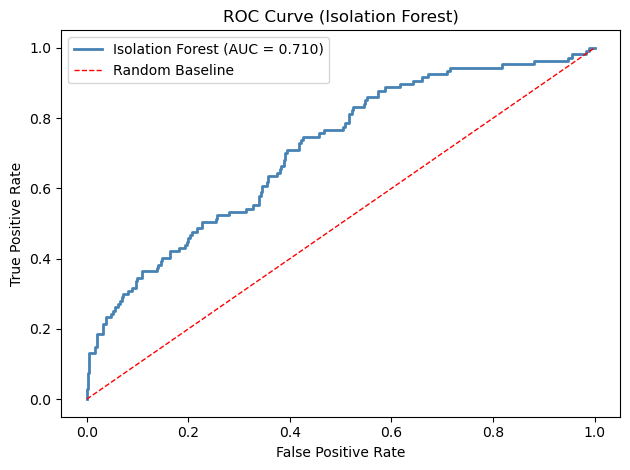

In [19]:
fpr, tpr, thresholds = roc_curve(y_test, opt_anomaly_scores)

plt.figure()
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Isolation Forest (AUC = {opt_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1, label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Isolation Forest)')
plt.legend()
plt.tight_layout()
plt.savefig("../visualizations/IF_ML/ROC_Curve.png")
plt.show()

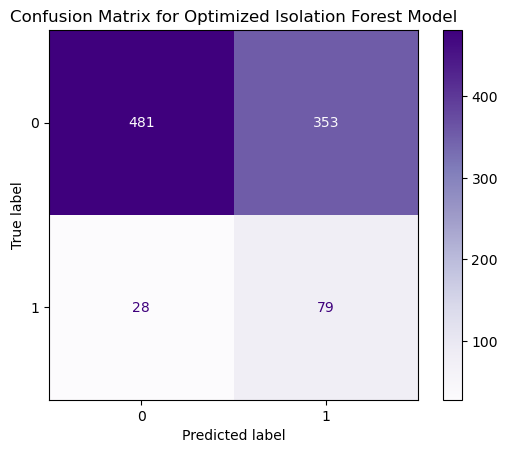

In [20]:

conf = confusion_matrix(y_test, opt_results)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=conf)
conf_plot.plot(cmap="Purples")
plt.title("Confusion Matrix for Optimized Isolation Forest Model")
plt.savefig("../visualizations/IF_ML/opt_if.png")
plt.show()

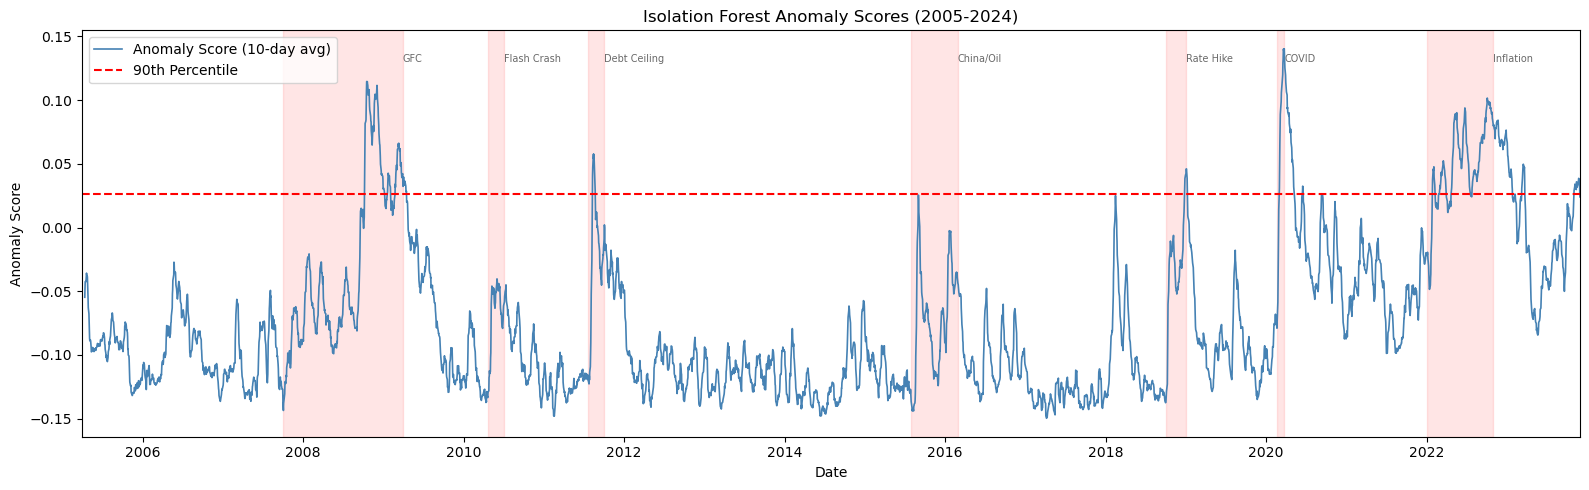

In [21]:
data['Date'] = pd.to_datetime(data['Date'])

crisis_periods = [
    ("2007-10-01", "2009-03-31", "GFC"),
    ("2010-04-23", "2010-07-02", "Flash Crash"),
    ("2011-07-22", "2011-10-03", "Debt Ceiling"),
    ("2015-08-01", "2016-02-29", "China/Oil"),
    ("2018-10-01", "2018-12-31", "Rate Hike"),
    ("2020-02-19", "2020-03-23", "COVID"),
    ("2022-01-01", "2022-10-31", "Inflation"),
]

all_scores = -optimal_model.decision_function(iso_data)
all_dates = data['Date'].reset_index(drop=True)
smoothed = pd.Series(all_scores).reset_index(drop=True).rolling(window=10).mean()

plt.figure(figsize=(16, 5))
plt.plot(all_dates, smoothed, color='steelblue', linewidth=1.2, label='Anomaly Score (10-day avg)')
plt.axhline(y=np.percentile(all_scores, 90), color='red', linestyle='--', label='90th Percentile')

for start, end, label in crisis_periods:
    plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.1, color='red')
    plt.text(pd.Timestamp(end), 0.13, label, fontsize=7, color='dimgray')

plt.xlim(all_dates.min(), all_dates.max())
plt.xlabel('Date')
plt.ylabel('Anomaly Score')
plt.title('Isolation Forest Anomaly Scores (2005-2024)')
plt.legend()
plt.tight_layout()
plt.savefig("../visualizations/IF_ML/anomalygraph.png")
plt.show()

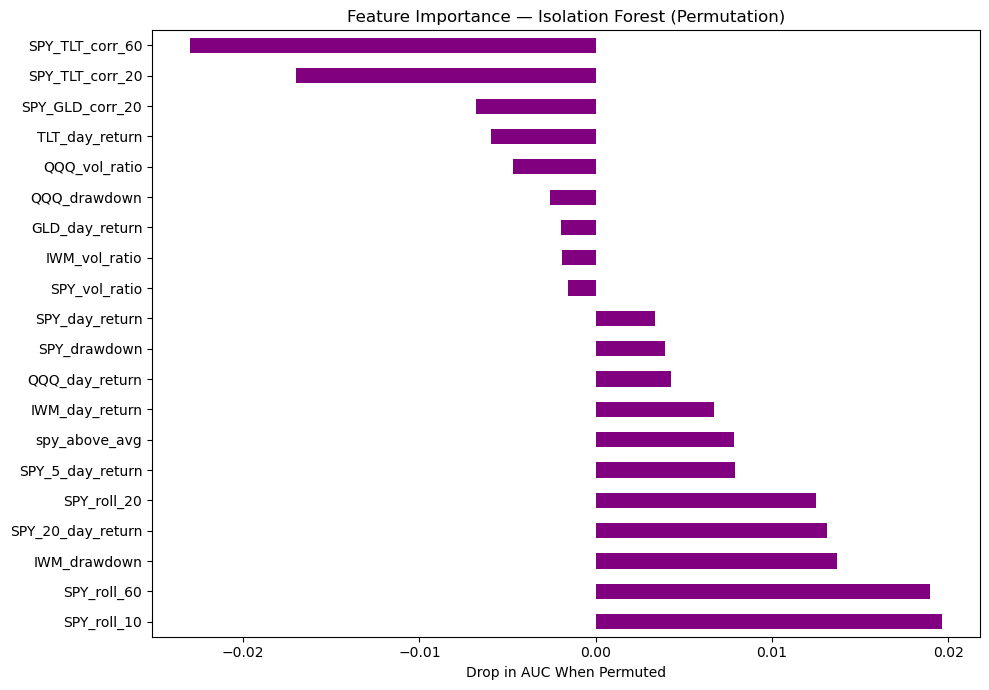

In [22]:
baseline_auc = roc_auc_score(y_test, opt_anomaly_scores)
importance = {}

for col in X_test.columns:
    X_permuted = X_test.copy()
    X_permuted[col] = np.random.permutation(X_permuted[col])
    permuted_scores = -optimal_model.decision_function(X_permuted)
    permuted_auc = roc_auc_score(y_test, permuted_scores)
    importance[col] = baseline_auc - permuted_auc

importance_df = pd.Series(importance).sort_values(ascending=False)

plt.figure(figsize=(10, 7))
importance_df.plot(kind='barh', color='purple')
plt.xlabel('Drop in AUC When Permuted')
plt.title('Feature Importance — Isolation Forest (Permutation)')
plt.tight_layout()
plt.savefig("../visualizations/IF_ML/feature_importance.png")
plt.show()

In [23]:
#New Model with only signifcant features

red_data = data[['SPY_roll_10', 'SPY_20_day_return', 'SPY_roll_60', 'SPY_roll_20', 'IWM_drawdown', 
                 'SPY_day_return', 'spy_above_avg', 'SPY_5_day_return', 'QQQ_day_return', 
                 'SPY_vol_ratio', 'SPY_drawdown', 'IWM_day_return']]

redX_train, redX_test, red_y_train, red_y_test = train_test_split(red_data, y, test_size=0.20, shuffle=False, random_state=101)

contam_vals = [0.05, 0.07, 0.09, 0.11, 0.12]
n_est_vals = [50, 100, 200, 300]
max_samps = [125, 256, 'auto']
max_features = [0.5, 0.75, 1.0]

RedResults = []

for c in contam_vals:
    for n in n_est_vals:
        for m in max_samps:
            for f in max_features:
                model = IsolationForest(random_state=101, contamination=c, n_estimators=n, max_samples=m, max_features=f)
                model.fit(redX_train)
                model_preds = np.where(model.predict(redX_test) == -1, 1, 0)
                vals = model.decision_function(redX_test)
                a_scores = -vals

                f1 = f1_score(red_y_test, model_preds)
                auc = roc_auc_score(red_y_test, a_scores)

                RedResults.append({
                    'contamination': c,
                    'estimators': n,
                    'samples': m,
                    'features': f,
                    'f1': f1,
                    'auc': auc
                })

red_optimized_df = pd.DataFrame(RedResults)

print(red_optimized_df.sort_values('auc', ascending=False))

     contamination  estimators samples  features        f1       auc
25            0.05         200    auto      0.75  0.343874  0.788913
22            0.05         200     256      0.75  0.343874  0.788913
61            0.07         200    auto      0.75  0.310400  0.788913
166           0.12         200     256      0.75  0.258228  0.788913
169           0.12         200    auto      0.75  0.258228  0.788913
..             ...         ...     ...       ...       ...       ...
36            0.07          50     125      0.50  0.317400  0.763531
72            0.09          50     125      0.50  0.309211  0.763531
108           0.11          50     125      0.50  0.286136  0.763531
144           0.12          50     125      0.50  0.272472  0.763531
0             0.05          50     125      0.50  0.337469  0.763531

[180 rows x 6 columns]


In [24]:
#Optimal Model - Reduced


red_optimal_model = IsolationForest(contamination=0.07, n_estimators=100, max_samples=256, max_features=0.75, random_state=101)
red_optimal_model.fit(redX_train)
red_opt_preds = red_optimal_model.predict(redX_test)
red_opt_results = np.where(red_opt_preds == -1, 1, 0)

red_opt_vals = red_optimal_model.decision_function(redX_test)
red_opt_anomaly_scores = -red_opt_vals
red_opt_auc = roc_auc_score(y_test, red_opt_anomaly_scores)

print(f'ROC-AUC: {red_opt_auc}')
print(classification_report(y_test, red_opt_results))

ROC-AUC: 0.7883637015621148
              precision    recall  f1-score   support

           0       0.97      0.53      0.69       834
           1       0.20      0.89      0.32       107

    accuracy                           0.57       941
   macro avg       0.59      0.71      0.51       941
weighted avg       0.89      0.57      0.65       941



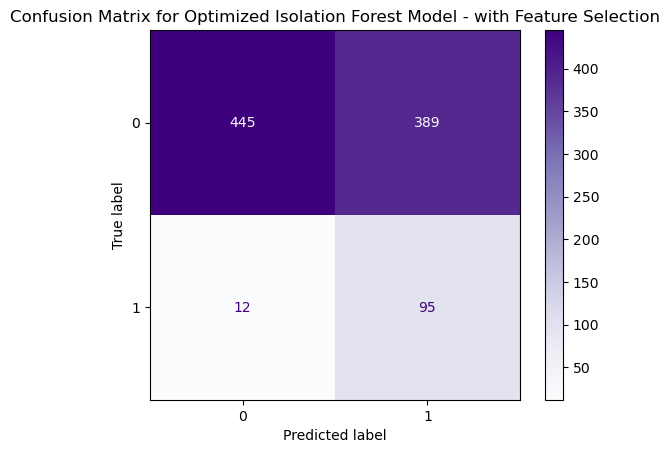

In [25]:

conf = confusion_matrix(y_test, red_opt_results)
conf_plot = ConfusionMatrixDisplay(confusion_matrix=conf)
conf_plot.plot(cmap="Purples")
plt.title("Confusion Matrix for Optimized Isolation Forest Model - with Feature Selection")
plt.savefig("../visualizations/IF_ML/red_opt_if.png")
plt.show()

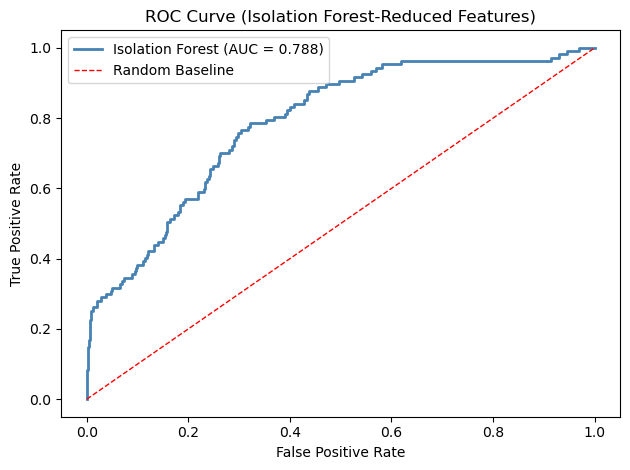

In [26]:
fpr, tpr, thresholds = roc_curve(y_test, red_opt_anomaly_scores)

plt.figure()
plt.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'Isolation Forest (AUC = {red_opt_auc:.3f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', linewidth=1, label='Random Baseline')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Isolation Forest-Reduced Features)')
plt.legend()
plt.tight_layout()
plt.savefig("../visualizations/IF_ML/Reduced_ROC_Curve.png")
plt.show()

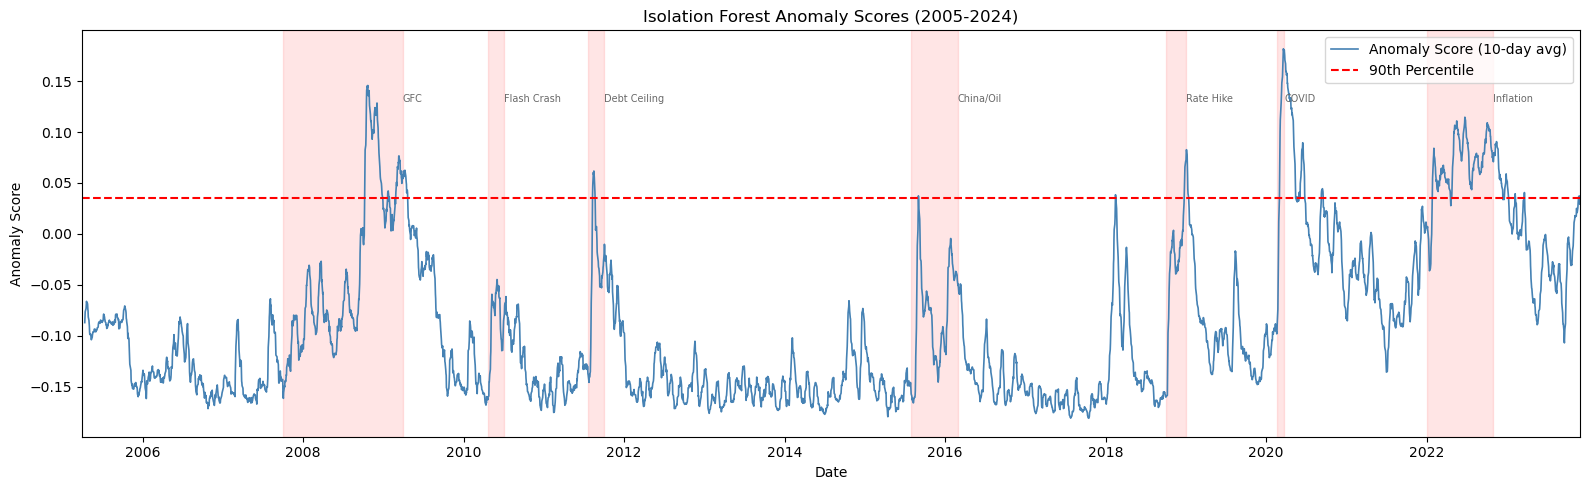

In [27]:
data['Date'] = pd.to_datetime(data['Date'])

crisis_periods = [
    ("2007-10-01", "2009-03-31", "GFC"),
    ("2010-04-23", "2010-07-02", "Flash Crash"),
    ("2011-07-22", "2011-10-03", "Debt Ceiling"),
    ("2015-08-01", "2016-02-29", "China/Oil"),
    ("2018-10-01", "2018-12-31", "Rate Hike"),
    ("2020-02-19", "2020-03-23", "COVID"),
    ("2022-01-01", "2022-10-31", "Inflation"),
]

all_scores = -red_optimal_model.decision_function(red_data)
all_dates = data['Date'].reset_index(drop=True)
smoothed = pd.Series(all_scores).reset_index(drop=True).rolling(window=10).mean()

plt.figure(figsize=(16, 5))
plt.plot(all_dates, smoothed, color='steelblue', linewidth=1.2, label='Anomaly Score (10-day avg)')
plt.axhline(y=np.percentile(all_scores, 90), color='red', linestyle='--', label='90th Percentile')

for start, end, label in crisis_periods:
    plt.axvspan(pd.Timestamp(start), pd.Timestamp(end), alpha=0.1, color='red')
    plt.text(pd.Timestamp(end), 0.13, label, fontsize=7, color='dimgray')

plt.xlim(all_dates.min(), all_dates.max())
plt.xlabel('Date')
plt.ylabel('Anomaly Score')
plt.title('Isolation Forest Anomaly Scores (2005-2024)')
plt.legend()
plt.tight_layout()
plt.savefig("../visualizations/IF_ML/reduced_anomalygraph.png")
plt.show()